# __Introduction__

Uber Ride Data Analysis 🚕
Introduction

Ride-sharing platforms generate large volumes of operational data that can be used to understand user behavior, service efficiency, and booking outcomes. Analyzing this data helps identify patterns related to ride demand, cancellations, payment preferences, and overall platform performance.

In this notebook, we perform an Exploratory Data Analysis (EDA) on an Uber ride bookings dataset. The goal is to clean the data, investigate important variables, and uncover insights about how ride bookings behave across different scenarios.

The analysis focuses on several key questions:

What are the most common ride outcomes (completed, cancelled, incomplete)?

What are the main reasons behind ride cancellations?

Which payment methods are most frequently used?

Are there noticeable patterns in ride bookings that could indicate operational issues?

To answer these questions, the notebook follows a structured workflow:

Data Loading and Inspection
Understanding the dataset structure, data types, and general statistics.

Data Cleaning and Preprocessing
Handling missing values, organizing columns, and preparing the dataset for analysis.

Feature Preparation
Creating unified variables such as the Reason column to combine different cancellation and ride outcome explanations.

Exploratory Data Analysis (EDA)
Using visualizations and summary statistics to identify patterns and trends within the dataset.

By the end of this notebook, we obtain a clearer view of ride booking behavior and highlight insights that could support further analysis or predictive modeling.

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import missingno
pd.set_option("display.max_columns", None)

In [2]:
df= pd.read_csv('ncr_ride_bookings.csv')
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

<Axes: >

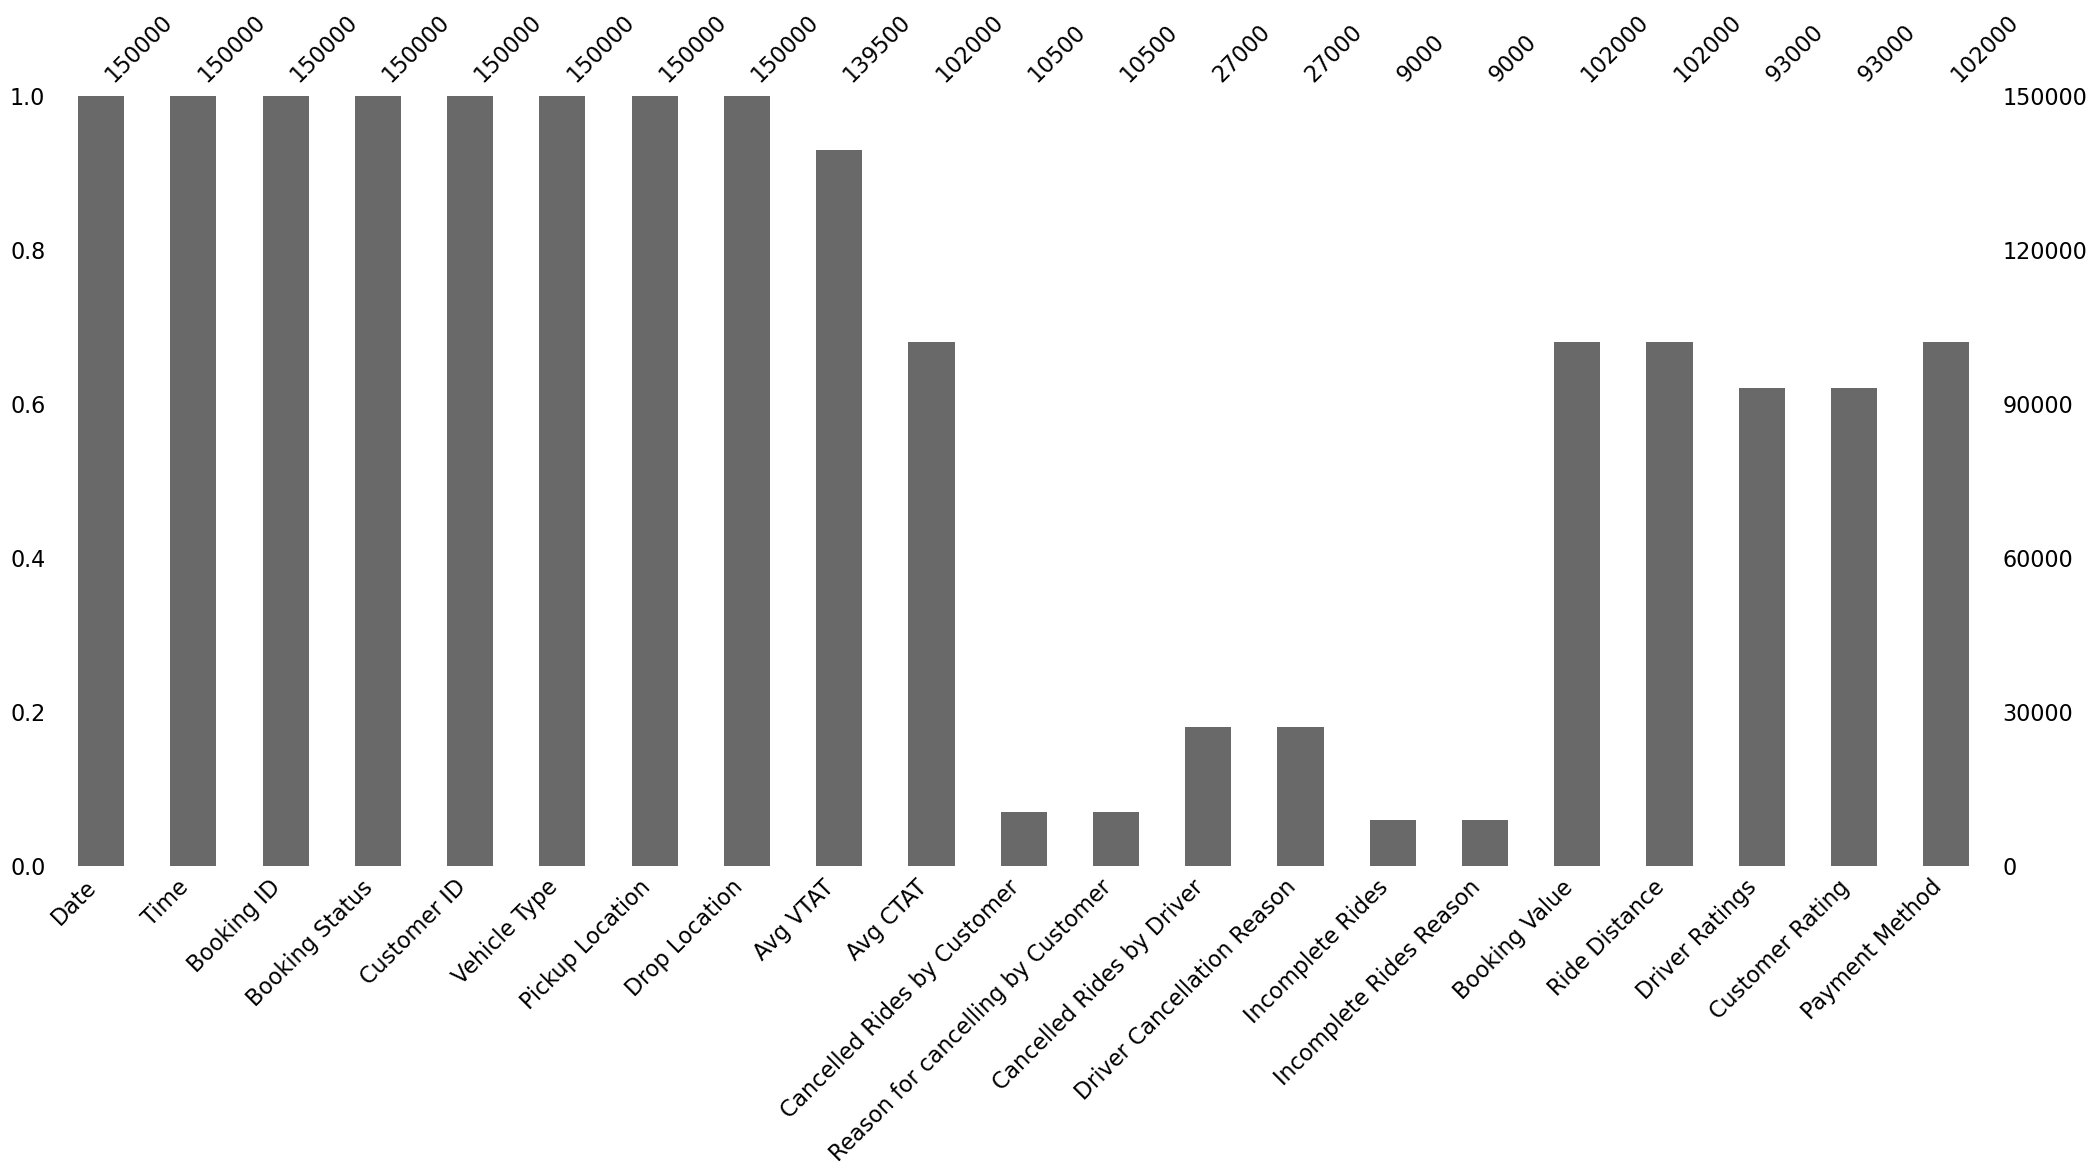

In [4]:
missingno.bar(df)

<Axes: >

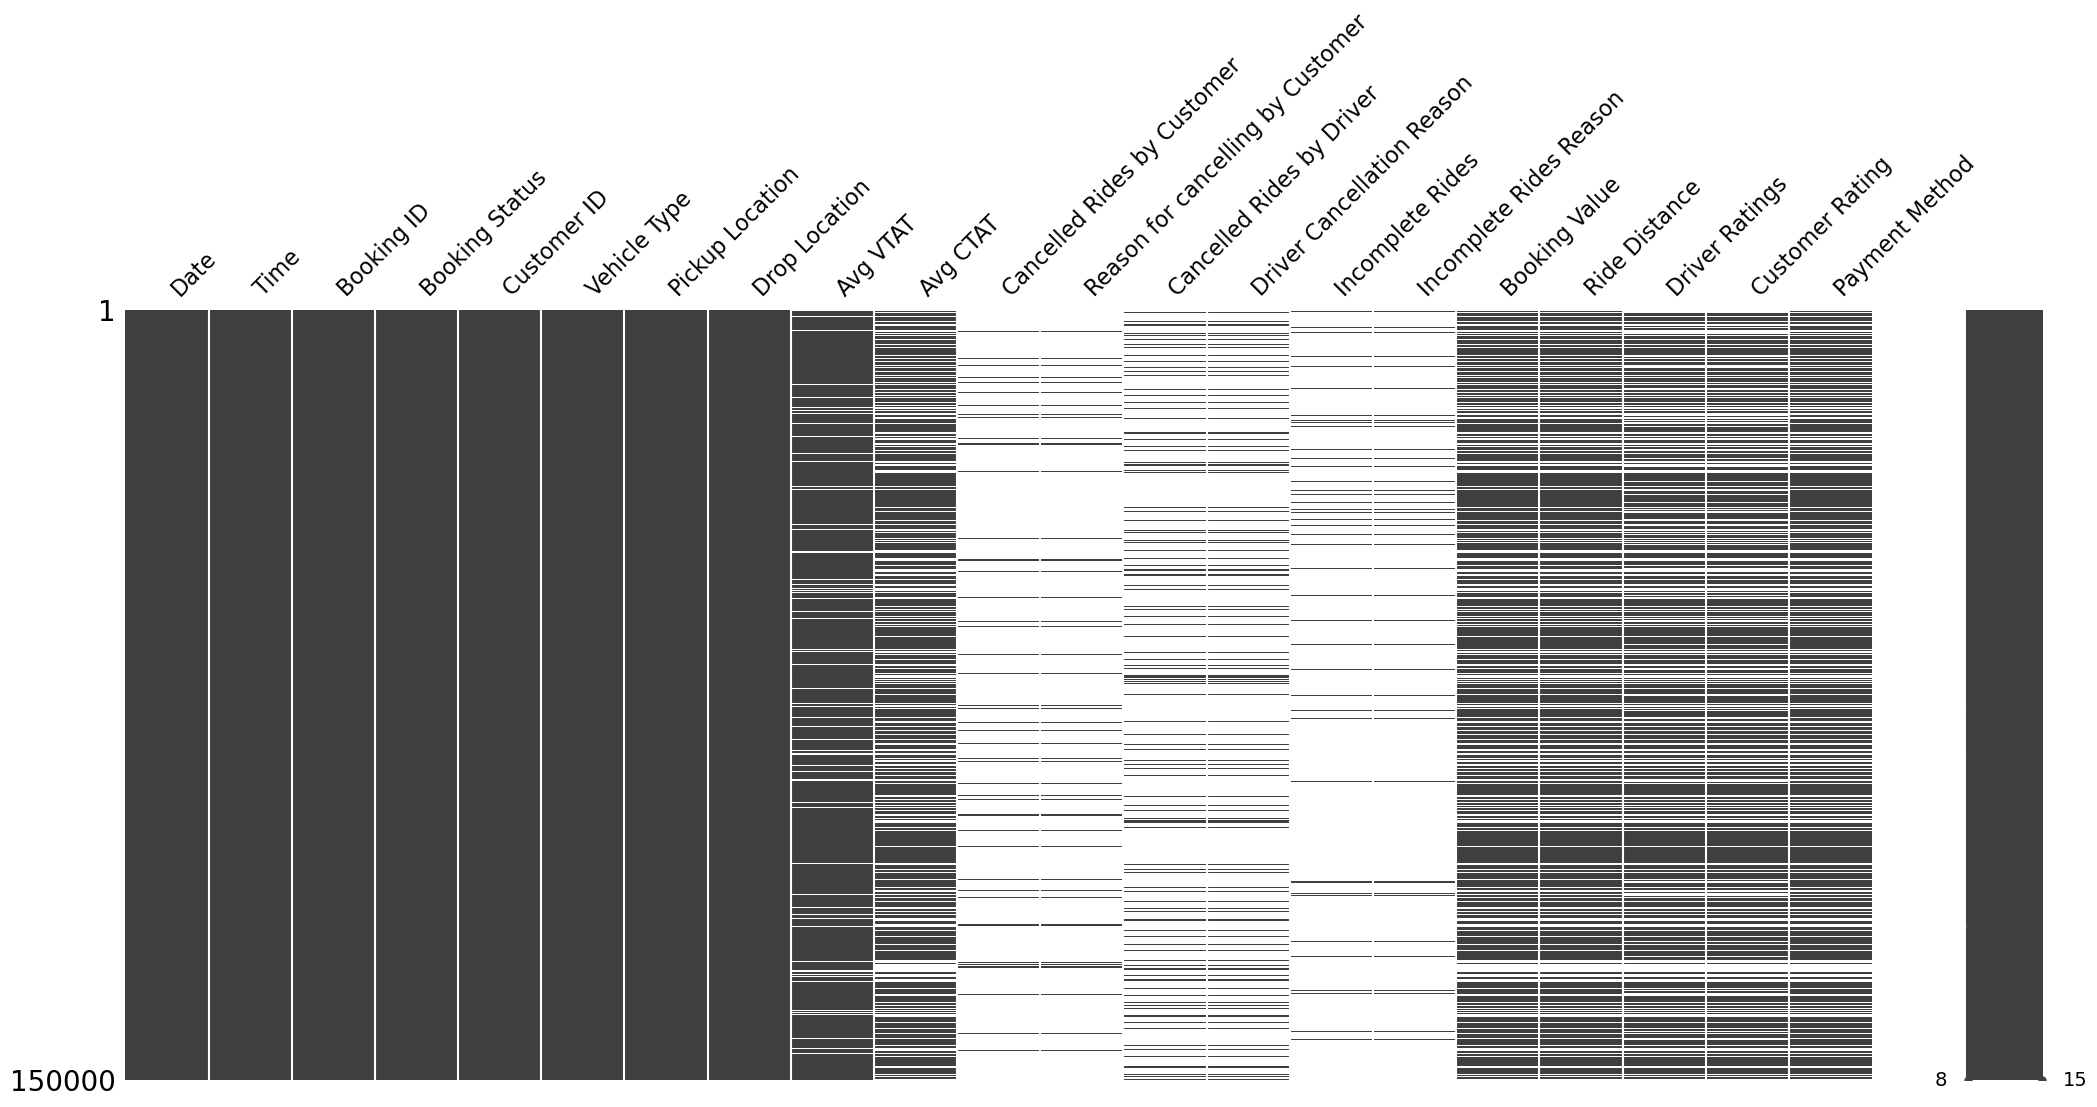

In [5]:
missingno.matrix(df)


In [6]:
# Avg VTAT , Avg CTAT
print(f"Avg VTAT: {df['Avg VTAT'].isna().sum()}")
print(f"Avg CTAT: {df['Avg CTAT'].isna().sum()}")

Avg VTAT: 10500
Avg CTAT: 48000


In [7]:
# handandling missing values by filling them with the mean of the respective columns
df['Avg VTAT']=df['Avg VTAT'].fillna(df['Avg VTAT'].mean())
df['Avg CTAT']=df['Avg CTAT'].fillna(df['Avg CTAT'].mean())


In [8]:
df.columns.to_list()

['Date',
 'Time',
 'Booking ID',
 'Booking Status',
 'Customer ID',
 'Vehicle Type',
 'Pickup Location',
 'Drop Location',
 'Avg VTAT',
 'Avg CTAT',
 'Cancelled Rides by Customer',
 'Reason for cancelling by Customer',
 'Cancelled Rides by Driver',
 'Driver Cancellation Reason',
 'Incomplete Rides',
 'Incomplete Rides Reason',
 'Booking Value',
 'Ride Distance',
 'Driver Ratings',
 'Customer Rating',
 'Payment Method']

In [9]:
#We discovered that when cancellation equals 1, there is a reason.

In [10]:
df['Booking Status'].unique()

array(['No Driver Found', 'Incomplete', 'Completed',
       'Cancelled by Driver', 'Cancelled by Customer'], dtype=object)

In [11]:
# We will create a new column called "Reason" and fill it with the respective reasons for cancellation and incomplete rides.
df['Reason']=np.nan

In [12]:
df['Reason'][df['Booking Status']=='Completed']='Everything was fine'
df['Reason'].unique()

C:\Users\El-Kerdawy\AppData\Local\Temp\ipykernel_17032\3975428506.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['Reason'][df['Booking Status']=='Completed']='Everything was fine'
C:\Users\El-Kerdawy\AppData\Local\Temp\ipykernel_1703

array([nan, 'Everything was fine'], dtype=object)

In [13]:
df['Reason'][df['Booking Status'] == "No Driver Found"] = "No Driver Available"
df['Reason'].unique()

array(['No Driver Available', nan, 'Everything was fine'], dtype=object)

In [14]:
df.loc[df['Incomplete Rides'] == 1, 'Reason'] = df['Incomplete Rides Reason']
df['Reason'].unique()

array(['No Driver Available', 'Vehicle Breakdown', 'Everything was fine',
       'Other Issue', nan, 'Customer Demand'], dtype=object)

In [15]:
df.loc[df['Cancelled Rides by Driver'] == 1 ,'Reason'] = df['Driver Cancellation Reason']
df['Reason'].unique()

array(['No Driver Available', 'Vehicle Breakdown', 'Everything was fine',
       'Other Issue', 'Personal & Car related issues',
       'Customer related issue', nan,
       'More than permitted people in there', 'Customer Demand',
       'The customer was coughing/sick'], dtype=object)

In [16]:
df.loc[df['Cancelled Rides by Customer'] == 1 ,'Reason']=df['Reason for cancelling by Customer']
df['Reason'].unique()

array(['No Driver Available', 'Vehicle Breakdown', 'Everything was fine',
       'Other Issue', 'Personal & Car related issues',
       'Customer related issue',
       'Driver is not moving towards pickup location',
       'More than permitted people in there', 'Driver asked to cancel',
       'Customer Demand', 'The customer was coughing/sick',
       'AC is not working', 'Change of plans', 'Wrong Address'],
      dtype=object)

In [17]:
# everything is fine :)
df['Reason'].isna().sum()

np.int64(0)

In [18]:
df.columns.to_list()

['Date',
 'Time',
 'Booking ID',
 'Booking Status',
 'Customer ID',
 'Vehicle Type',
 'Pickup Location',
 'Drop Location',
 'Avg VTAT',
 'Avg CTAT',
 'Cancelled Rides by Customer',
 'Reason for cancelling by Customer',
 'Cancelled Rides by Driver',
 'Driver Cancellation Reason',
 'Incomplete Rides',
 'Incomplete Rides Reason',
 'Booking Value',
 'Ride Distance',
 'Driver Ratings',
 'Customer Rating',
 'Payment Method',
 'Reason']

In [19]:
#now we drop column we don't need 
df.drop(columns=['Incomplete Rides Reason','Incomplete Rides','Driver Cancellation Reason','Cancelled Rides by Driver', 'Cancelled Rides by Customer','Reason for cancelling by Customer'], axis=1, inplace=True)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 16 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Date             150000 non-null  object 
 1   Time             150000 non-null  object 
 2   Booking ID       150000 non-null  object 
 3   Booking Status   150000 non-null  object 
 4   Customer ID      150000 non-null  object 
 5   Vehicle Type     150000 non-null  object 
 6   Pickup Location  150000 non-null  object 
 7   Drop Location    150000 non-null  object 
 8   Avg VTAT         150000 non-null  float64
 9   Avg CTAT         150000 non-null  float64
 10  Booking Value    102000 non-null  float64
 11  Ride Distance    102000 non-null  float64
 12  Driver Ratings   93000 non-null   float64
 13  Customer Rating  93000 non-null   float64
 14  Payment Method   102000 non-null  object 
 15  Reason           150000 non-null  object 
dtypes: float64(6), object(10)
memory usage

In [21]:
df['Booking Status'][df['Booking Status']=='Completed'].count()
# Booking Value    102000 non-null  float64
# Ride Distance    102000 non-null  float64
# Payment Method   102000 non-null  object 
# Booking Status is 93000 how ??


np.int64(93000)

In [22]:
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Reason
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,8.456352,29.149636,NaN,NaN,NaN,NaN,NaN,No Driver Available
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.900000,14.000000,237.0,5.73,NaN,NaN,UPI,Vehicle Breakdown
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.400000,25.800000,627.0,13.58,4.9,4.9,Debit Card,Everything was fine
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.100000,28.500000,416.0,34.02,4.6,5.0,UPI,Everything was fine
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.300000,19.600000,737.0,48.21,4.1,4.3,UPI,Everything was fine


In [23]:
df.describe()

,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,150000.000000,150000.000000,102000.000000,102000.000000,93000.000000,93000.000000
mean,8.456352,29.149636,508.295912,24.637012,4.230992,4.404584
std,3.639092,7.341242,395.805774,14.002138,0.436871,0.437819
min,2.000000,10.000000,50.000000,1.000000,3.000000,3.000000
25%,5.600000,25.000000,234.000000,12.460000,4.100000,4.200000
50%,8.456352,29.149636,414.000000,23.720000,4.300000,4.500000
75%,11.000000,32.900000,689.000000,36.820000,4.600000,4.800000
max,20.000000,45.000000,4277.000000,50.000000,5.000000,5.000000


In [ ]:
df['Avg VTAT'].fillna(-1, inplace=True)
df['Avg CTAT'].fillna(-1, inplace=True)
df['Booking Value'].fillna(-1, inplace=True)
df['Ride Distance'].fillna(-1, inplace=True)
df['Driver Ratings'].fillna(-1, inplace=True)
df['Customer Rating'].fillna(-1, inplace=True)
df['Payment Method'].fillna("NO Payment", inplace=True)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 19 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Date             150000 non-null  datetime64[ns]
 1   Time             150000 non-null  object        
 2   Booking ID       150000 non-null  object        
 3   Booking Status   150000 non-null  object        
 4   Customer ID      150000 non-null  object        
 5   Vehicle Type     150000 non-null  object        
 6   Pickup Location  150000 non-null  object        
 7   Drop Location    150000 non-null  object        
 8   Avg VTAT         150000 non-null  float64       
 9   Avg CTAT         150000 non-null  float64       
 10  Booking Value    150000 non-null  float64       
 11  Ride Distance    150000 non-null  float64       
 12  Driver Ratings   150000 non-null  float64       
 13  Customer Rating  150000 non-null  float64       
 14  Payment Method   150

C:\Users\El-Kerdawy\AppData\Local\Temp\ipykernel_17032\3772150943.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Hour'] = pd.to_datetime(df['Time']).dt.hour


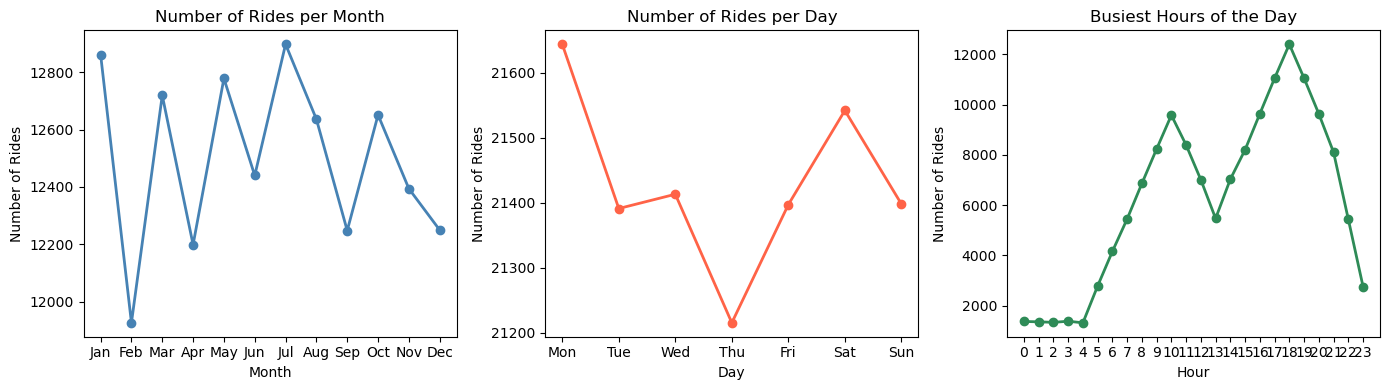

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4)) 

df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M')
monthly = df.groupby('Month').size().reset_index(name='Rides')
monthly['Month'] = monthly['Month'].dt.strftime('%b').astype(str)
axes[0].plot(monthly['Month'], monthly['Rides'], marker='o', color='steelblue', linewidth=2, markersize=6)
axes[0].set_title('Number of Rides per Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Number of Rides')

df['Day'] = df['Date'].dt.strftime('%a')
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily = df.groupby('Day').size().reset_index(name='Rides')
daily['Day'] = pd.Categorical(daily['Day'], categories=day_order, ordered=True)
daily = daily.sort_values('Day')
axes[1].plot(daily['Day'], daily['Rides'], marker='o', color='tomato', linewidth=2, markersize=6)
axes[1].set_title('Number of Rides per Day')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Number of Rides')

df['Hour'] = pd.to_datetime(df['Time']).dt.hour
hourly = df.groupby('Hour').size().reset_index(name='Rides')
axes[2].plot(hourly['Hour'], hourly['Rides'], marker='o', color='seagreen', linewidth=2, markersize=6)
axes[2].set_title('Busiest Hours of the Day')
axes[2].set_xlabel('Hour')
axes[2].set_ylabel('Number of Rides')
axes[2].set_xticks(range(0, 24))

plt.tight_layout()  
plt.show()

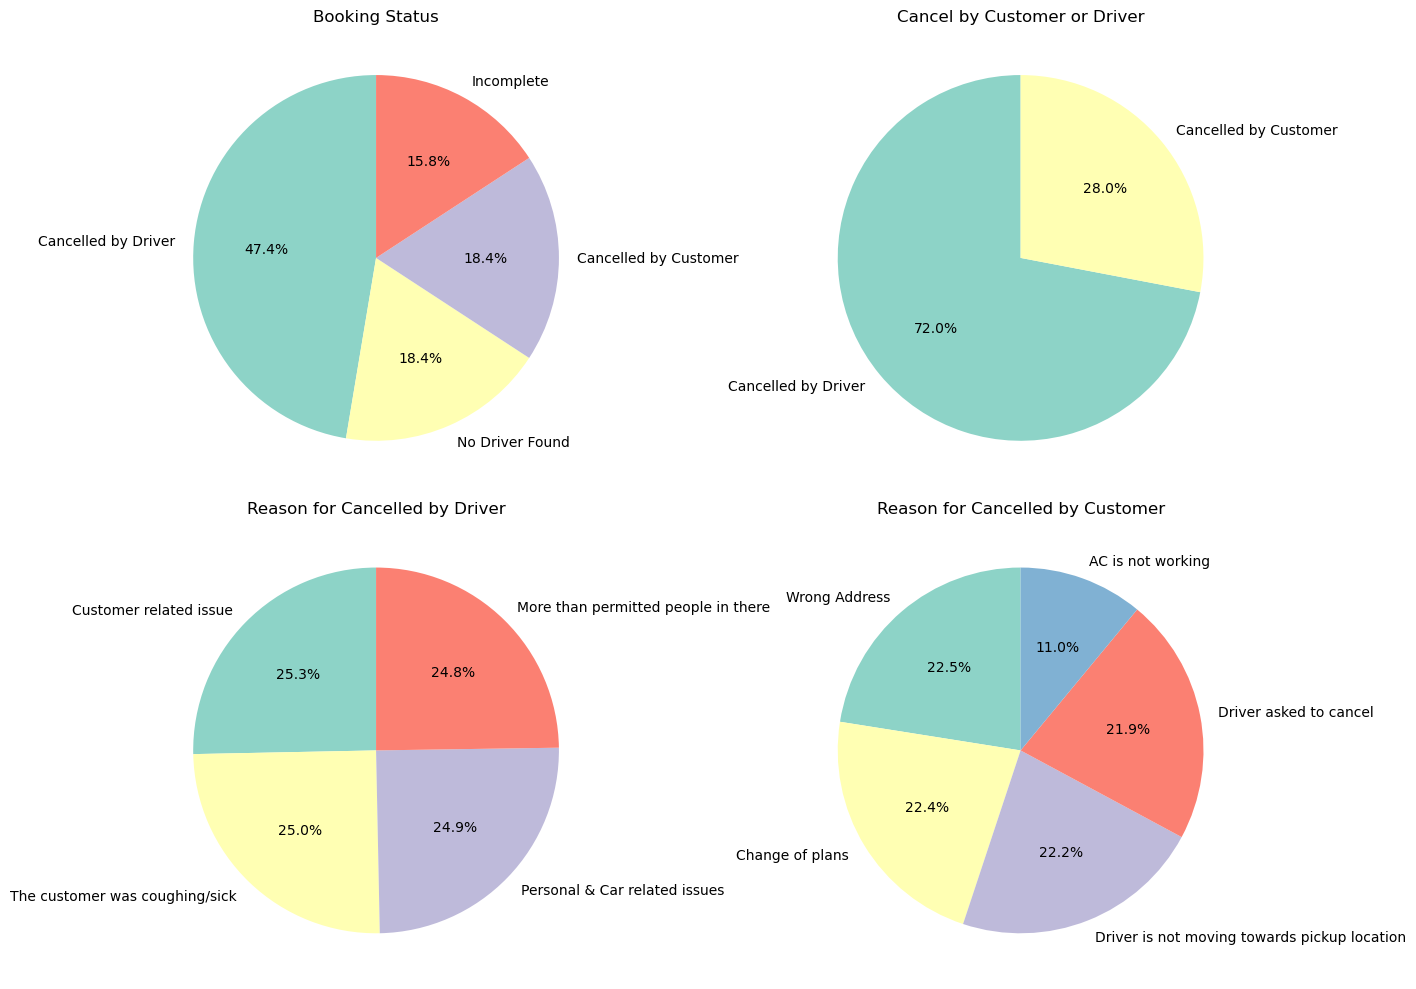

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cancel_group = df['Booking Status'].apply(lambda x: x if x != 'Completed' else None).value_counts()
axes[0][0].pie(cancel_group, labels=cancel_group.index, autopct="%1.1f%%", startangle=90, colors=plt.cm.Set3.colors)
axes[0][0].set_title('Booking Status')

cancel_by_customer_driver_group = df['Booking Status'][(df['Booking Status'] == 'Cancelled by Customer') | (df['Booking Status'] == 'Cancelled by Driver')].value_counts()
axes[0][1].pie(cancel_by_customer_driver_group, labels=cancel_by_customer_driver_group.index, autopct="%1.1f%%", startangle=90, colors=plt.cm.Set3.colors)
axes[0][1].set_title('Cancel by Customer or Driver')

cancel_by_driver_group = df[df['Booking Status'] == 'Cancelled by Driver']['Reason'].value_counts()
axes[1][0].pie(cancel_by_driver_group, labels=cancel_by_driver_group.index, autopct="%1.1f%%", startangle=90, colors=plt.cm.Set3.colors)
axes[1][0].set_title('Reason for Cancelled by Driver')

cancel_by_customer_group = df[df['Booking Status'] == 'Cancelled by Customer']['Reason'].value_counts()
axes[1][1].pie(cancel_by_customer_group.values, labels=cancel_by_customer_group.index, autopct='%1.1f%%', colors=plt.cm.Set3.colors, startangle=90)
axes[1][1].set_title('Reason for Cancelled by Customer')

plt.tight_layout()
plt.show()  

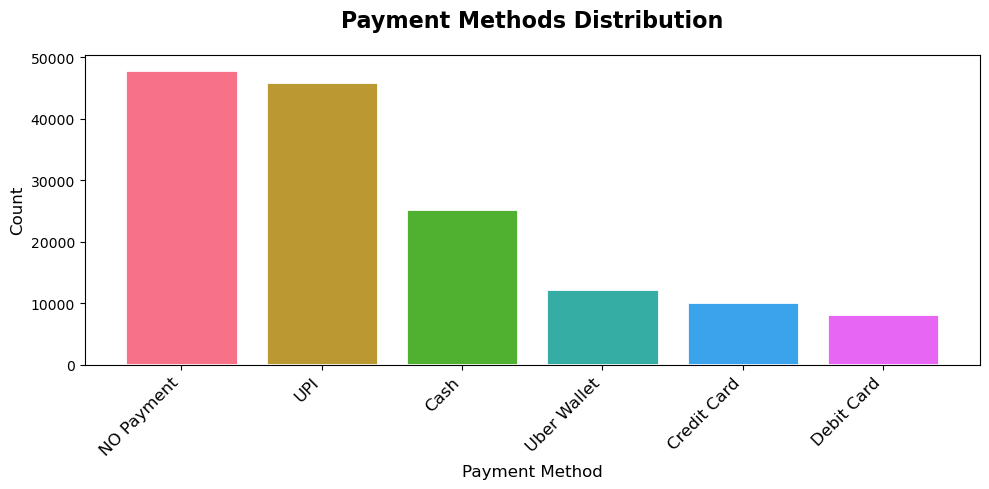

In [33]:
Reason_count = df['Payment Method'].value_counts()
colors = sns.color_palette("husl", len(Reason_count))
plt.figure(figsize=(10, 5))

plt.bar(
    Reason_count.index,
    Reason_count.values,
    color=colors,
    edgecolor='white',
    linewidth=2
)

plt.title('Payment Methods Distribution', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Payment Method', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(fontsize=12, rotation=45, ha='right')
plt.tight_layout()
plt.show()

<Figure size 1400x500 with 0 Axes>

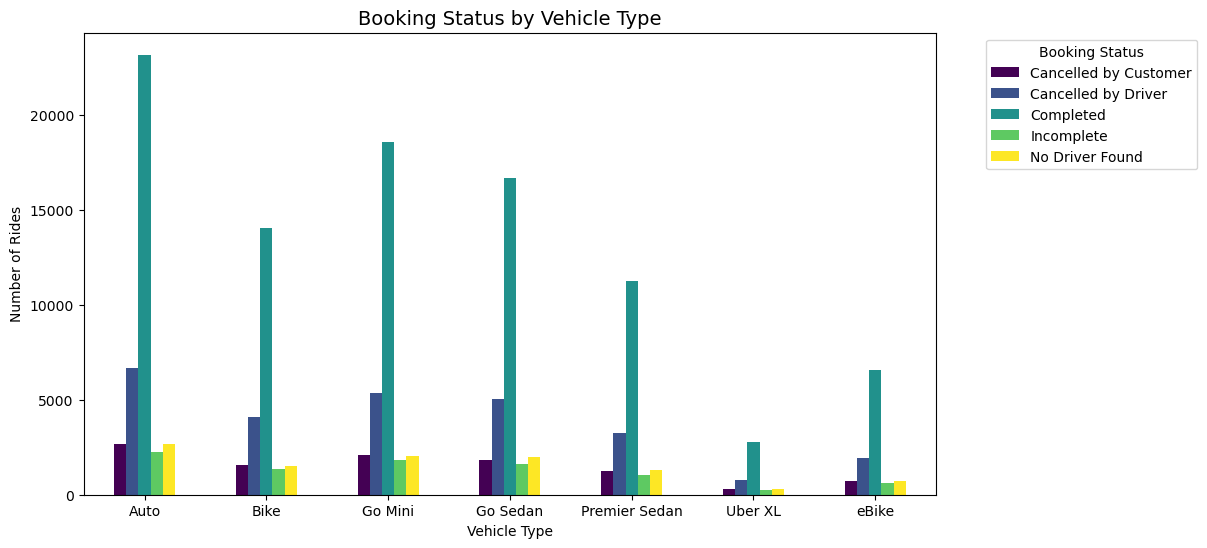

In [28]:
plt.figure(figsize=(14, 5))
pivot_status = pd.pivot_table(
    df,
    index='Vehicle Type',
    columns='Booking Status',
    values='Booking ID',
    aggfunc='count',
    fill_value=0
)

pivot_status.plot(
    kind='bar',
    figsize=(11,6),
    colormap='viridis'
)

plt.title("Booking Status by Vehicle Type", fontsize=14)
plt.xlabel("Vehicle Type")
plt.ylabel("Number of Rides")
plt.xticks(rotation=0)
plt.legend(title='Booking Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

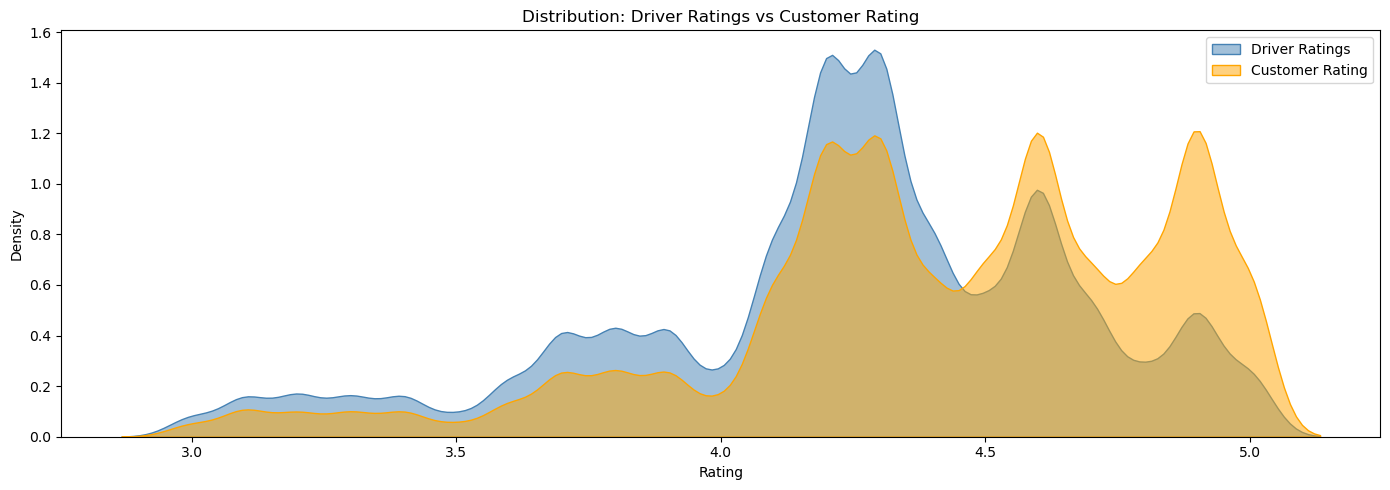

In [29]:

plt.figure(figsize=(14, 5))

sns.kdeplot(df['Driver Ratings'], label='Driver Ratings', fill=True, alpha=0.5, color='steelblue')
sns.kdeplot(df['Customer Rating'], label='Customer Rating', fill=True, alpha=0.5, color='orange')

plt.title('Distribution: Driver Ratings vs Customer Rating')
plt.xlabel('Rating')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

# Conclusion

## Project Summary

In this notebook, we explored the Uber ride bookings dataset to better understand ride outcomes, customer behavior, and operational patterns.

### Data Cleaning
Several preprocessing steps were performed to prepare the dataset for analysis:
- Checked the dataset structure using `info()` and `describe()`.
- Investigated missing values using **Missingno visualizations**.
- Handled missing values in important columns such as **Avg VTAT**.
- Created a new column called **Reason** to unify different cancellation and ride outcome explanations.

### Data Transformation
To make the dataset easier to analyze:
- Different ride outcomes were grouped under a single **Reason** column.
- Cancellation reasons from both **drivers and customers** were combined.
- Incomplete ride reasons were also integrated into the same column.

### Exploratory Data Analysis
Several visualizations were created to explore patterns in the data:
- Distribution of **booking statuses**
- Analysis of **payment methods**
- Comparisons between different ride outcomes
- General distribution plots for key variables

### Key Insights
From the analysis, we observed that:
- Ride outcomes vary significantly depending on operational factors such as driver availability.
- Cancellation reasons differ between **drivers and customers**.
- Payment method usage shows clear customer preferences.
- Some operational metrics contain missing values that require careful handling before modeling.

### Final Thoughts
This exploratory analysis provides a clearer understanding of ride booking behavior and cancellation patterns.  
The cleaned dataset and derived features can be useful for further analysis or for building machine learning models such as:
- Ride cancellation prediction
- Driver availability analysis
- Customer behavior modeling